![image.png](https://i.imgur.com/a3uAqnb.png)


#  ML Regression for Sales.

---
In this lab, you'll learn how to preprocess tabular data and implement:


1. **Linear Regression** (from scratch)

2. **Ridge Regression**

3. **LASSO Regression**

4. **Support Vector Machine (Regressor)**

5. **Decision Tree Regressor**

6. **Random Forest Regressor**

7. **LightGBM Regressor**

8. **CatBoost Regressor**

---

# 📊 **Data**
https://www.kaggle.com/datasets/bumba5341/advertisingcsv

> This dataset's goal is to predict `Sales` (**regression**) based on advertising budgets for TV, Radio, and Newspaper.


# 1️⃣ Import Libraries


In [1]:
from IPython.display import clear_output

%pip install kagglehub catboost lightgbm tqdm -q

clear_output()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from tqdm import tqdm

%matplotlib inline

# 2️⃣ Read the Data


In [3]:
# Download latest version
path = kagglehub.dataset_download("bumba5341/advertisingcsv")

print("Path to dataset files:", path)

100%|██████████| 2.26k/2.26k [00:00<00:00, 4.19MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bumba5341/advertisingcsv/versions/1


In [4]:
csv_path = os.path.join(path, "Advertising.csv")

df = pd.read_csv(csv_path)
df = df.drop(columns="Unnamed: 0", axis=1)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


# 3️⃣ Exploratory Data Analysis (EDA)

**Rule of thumb checklist:**

| Question | If YES | If NO |
|----------|--------|-------|
|  **Is the target skewed?** | Consider log transform | Proceed |
|  **Missing values?** | Impute or drop | Proceed |
|  **Categorical columns?** | Encode them | Proceed |
|  **Duplicates?** | Drop them | Proceed |
|  **Different scales?** | Standardize (except tree models) | Proceed |


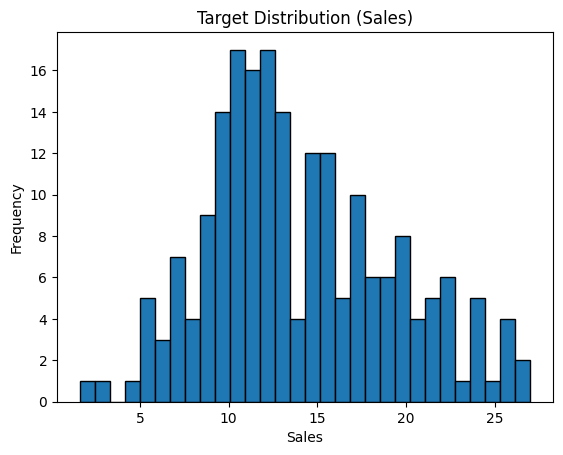

In [6]:
# 1. What does our target variable (charges) look like?
def check_target_distribution(df, target_column):
  df[target_column].hist(bins=30, edgecolor='black')

  plt.title(f"Target Distribution ({target_column})")
  plt.xlabel(target_column)
  plt.ylabel("Frequency")
  plt.grid(False)

  plt.show()

check_target_distribution(df, "Sales")

> **Rule of thumb:** For regression, if the target is heavily skewed, we might apply a log transform. However, for this lab we'll work with the raw values.


In [7]:
# 2. Do we have missing values?
def check_missing_values(df):
  missing_values = df.isnull().sum()
  print("Missing Values per Column:")
  print(missing_values[missing_values > 0])
  if missing_values.any():
    print("\nHandle Missing Values as needed.")
  else:
    print("\nNo Missing Values Found.")

check_missing_values(df)

Missing Values per Column:
Series([], dtype: int64)

No Missing Values Found.


In [8]:
# 3. Do we have categorical columns?
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:", list(categorical_cols))

Categorical Columns: []


> We don't have categorical columns. If we did, we would need to encode them (convert them into numbers) for our models.

In [9]:
# 4. Do we have duplicate samples?
def check_duplicates(df):
  duplicates = df.duplicated().sum()
  print(f"Number of Duplicate Samples: {duplicates}")
  if duplicates > 0:
    print("Dropping Duplicates...")
    df.drop_duplicates(inplace=True)
    print("Duplicates Dropped.")
  else:
    print("No Duplicate Samples Found.")

check_duplicates(df)

Number of Duplicate Samples: 0
No Duplicate Samples Found.


> **Rule of thumb:** If duplicates exist, drop them with `df.drop_duplicates(inplace=True)`


In [10]:
# 5. Do we have different scales in the data?
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


> **Rule of thumb:** If features have vastly different ranges, then **scale them**. Scaling won't hurt, and it's recommended regardless.
>
> Tree models (RF, LightGBM, CatBoost) don't need scaling, but Linear Regression, Ridge, LASSO, SVM do!


In [13]:
from sklearn.preprocessing import MinMaxScaler

features = df.columns.drop("Sales")  # DON'T SCALE THE TARGET
numerical_cols = df[features].select_dtypes(include='number').columns
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[numerical_cols])
df.head()

,TV,Radio,Newspaper,Sales
0,0.775786,0.762097,0.605981,22.1
1,0.148123,0.792339,0.394019,10.4
2,0.055800,0.925403,0.606860,9.3
3,0.509976,0.832661,0.511873,18.5
4,0.609063,0.217742,0.510994,12.9


# 4️⃣ Training our Regression Models

> We need to split our data into **X** (features) and **y** (target).


In [14]:
X = df.drop("Sales", axis=1).astype(float)
y = df['Sales'].astype(float)

In [ ]:
import numpy as np
class LinearRegression:
    def __init__(self, learning_rate=0.001, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = [] 

    def fit(self, X, y):
      #x = (4650, 4) y = (4650,)
        n_samples, n_features = X.shape #(row,col)

        # init parameters
        self.weights = np.zeros(n_features) #[0,0,0,0] weight(4,)
        self.bias = 0

        # gradient descent
        for _ in range(self.n_iters):
            y_predicted = X @ self.weights + self.bias 

            # حساب الخسارة الحالية وتخزينها
            current_loss = mean_squared_error(y, y_predicted)
            self.loss_history.append(current_loss)

            # compute gradients
            #1/n sumishion(-2x(y-y_hat))
            dw = (1 / n_samples) * ( X.T @ (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        y_approximated = X @ self.weights + self.bias
        return y_approximated


def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    sse = np.sum((y_true - y_pred)**2)
    sst = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (sse / sst)

In [26]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error as sklearn_mse, mean_absolute_error, r2_score

# Storage for linear regression results for each fold
lr_losses = []
lr_mse = []
lr_rmse = []
lr_r2 = []
n_splits = 5  # K=5 Folds

# 5-Fold Cross-Validation, shuffled
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
  print(f"\nFold {fold_idx + 1}/{n_splits}")

  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  model = LinearRegression(learning_rate=0.1, n_iters=500)

  # Train
  model.fit(X_train.values, y_train.values)

  # Validate
  y_pred = model.predict(X_test.values)

  # Calculate evaluation metrics
  mse = sklearn_mse(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  # Store results
  lr_losses.append(model.loss_history)
  lr_mse.append(mse)
  lr_rmse.append(rmse)
  lr_r2.append(r2)


Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5


In [27]:
print("Linear Regression Results")
print(f"  Average MSE: {np.mean(lr_mse):.4f}")
print(f"  Average RMSE: {np.mean(lr_rmse):.4f}")
print(f"  Average R2:  {np.mean(lr_r2):.4f}")

Linear Regression Results
  Average MSE: 2.9985
  Average RMSE: 1.7167
  Average R2:  0.8819


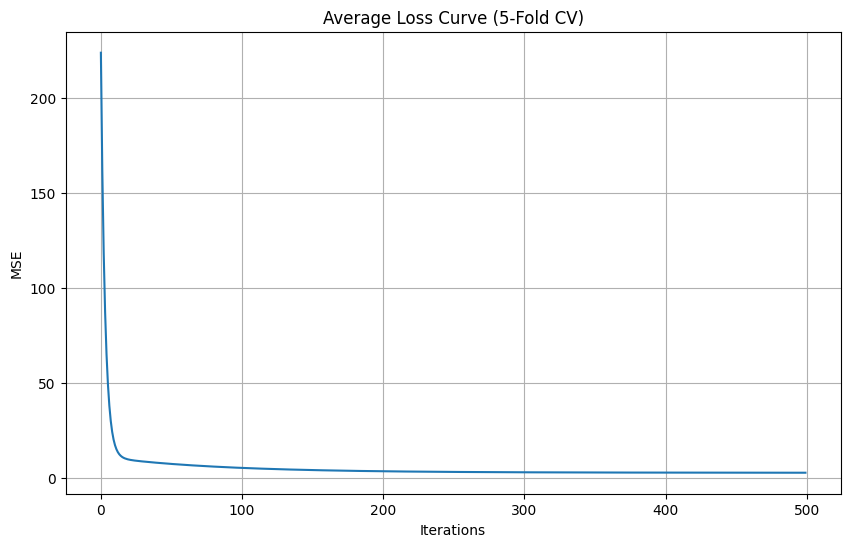

In [ ]:
avg_loss = np.mean(np.array(lr_losses), axis=0)
plt.figure(figsize=(10,6))
plt.plot(avg_loss)
plt.title("Average Loss Curve (5-Fold CV)")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.grid(True)
plt.show()
